# Step 1：数据下载 + 清洗 + 基础指标计算

 ### 第一步：下载历史市场数据

In [9]:
import yfinance as yf
import pandas as pd
import os

# 创建 data 文件夹，避免保存 csv 时报错
os.makedirs("data", exist_ok=True)

tickers = {
    "EURUSD": "EURUSD=X",
    "AUDUSD": "AUDUSD=X",
    "GOLD": "GC=F",
    "NASDAQ100": "^NDX",
    "SP500": "^GSPC"
}

data_list = []

for asset_name, ticker in tickers.items():
    print(f"Downloading {asset_name}: {ticker}")
    
    temp = yf.download(
        ticker,
        start="2021-01-01",
        end="2025-12-31",
        auto_adjust=False,
        progress=False
    )
    
    # 如果下载失败，跳过并提示
    if temp.empty:
        print(f"Warning: No data downloaded for {asset_name}")
        continue
    
    # 处理 yfinance 可能返回 MultiIndex columns 的情况
    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = temp.columns.get_level_values(0)
    
    temp = temp.reset_index()
    
    # 只保留我们需要的字段
    temp = temp[["Date", "Open", "High", "Low", "Close", "Volume"]]
    
    temp["asset"] = asset_name
    temp["ticker"] = ticker
    
    data_list.append(temp)

market_data = pd.concat(data_list, ignore_index=True)

market_data.to_csv("data/raw_market_data.csv", index=False)

market_data.head()

Price,Date,Open,High,Low,Close,Volume,asset,ticker
0,2021-01-01,1.217285,1.221699,1.213499,1.218027,0,EURUSD,EURUSD=X
1,2021-01-04,1.224905,1.230999,1.217137,1.225070,0,EURUSD,EURUSD=X
2,2021-01-05,1.225295,1.229483,1.224995,1.225160,0,EURUSD,EURUSD=X
3,2021-01-06,1.229861,1.235025,1.226693,1.230027,0,EURUSD,EURUSD=X
4,2021-01-07,1.233776,1.234568,1.224665,1.234111,0,EURUSD,EURUSD=X


In [13]:
market_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362 entries, 0 to 6361
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6362 non-null   datetime64[ns]
 1   Open    6362 non-null   float64       
 2   High    6362 non-null   float64       
 3   Low     6362 non-null   float64       
 4   Close   6362 non-null   float64       
 5   Volume  6362 non-null   int64         
 6   asset   6362 non-null   object        
 7   ticker  6362 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 397.8+ KB


In [14]:
market_data["asset"].value_counts()

asset
EURUSD       1299
AUDUSD       1299
GOLD         1256
NASDAQ100    1254
SP500        1254
Name: count, dtype: int64

### 第二步：计算 return、volatility 和 moving average

In [15]:
import numpy as np

df = market_data.copy()

# 确保日期格式正确
df["Date"] = pd.to_datetime(df["Date"])

# 按资产和日期排序
df = df.sort_values(["asset", "Date"]).reset_index(drop=True)

# 计算每日简单收益率
df["daily_return"] = df.groupby("asset")["Close"].pct_change()

# 计算对数收益率
df["log_return"] = np.log(df["Close"] / df.groupby("asset")["Close"].shift(1))

# 计算 20 日滚动波动率
df["volatility_20d"] = (
    df.groupby("asset")["daily_return"]
      .rolling(window=20)
      .std()
      .reset_index(level=0, drop=True)
)

# 计算 20 日均线
df["ma_20"] = (
    df.groupby("asset")["Close"]
      .rolling(window=20)
      .mean()
      .reset_index(level=0, drop=True)
)

# 计算 50 日均线
df["ma_50"] = (
    df.groupby("asset")["Close"]
      .rolling(window=50)
      .mean()
      .reset_index(level=0, drop=True)
)

df.head()

Price,Date,Open,High,Low,Close,Volume,asset,ticker,daily_return,log_return,volatility_20d,ma_20,ma_50
0,2021-01-01,0.77718,0.820760,0.769823,0.770297,0,AUDUSD,AUDUSD=X,NaN,NaN,NaN,NaN,NaN
1,2021-01-04,0.77130,0.774200,0.765660,0.771230,0,AUDUSD,AUDUSD=X,0.001211,0.001210,NaN,NaN,NaN
2,2021-01-05,0.76698,0.775300,0.766289,0.767100,0,AUDUSD,AUDUSD=X,-0.005355,-0.005370,NaN,NaN,NaN
3,2021-01-06,0.77628,0.782038,0.773431,0.776600,0,AUDUSD,AUDUSD=X,0.012384,0.012308,NaN,NaN,NaN
4,2021-01-07,0.78154,0.781540,0.772770,0.781700,0,AUDUSD,AUDUSD=X,0.006567,0.006546,NaN,NaN,NaN


#### 清理缺失值：rolling window 前 50 天没有均线，所以会有 NaN要删掉。

In [16]:
processed_data = df.dropna().copy()

processed_data.to_csv("data/processed_market_data.csv", index=False)

processed_data.head()

Price,Date,Open,High,Low,Close,Volume,asset,ticker,daily_return,log_return,volatility_20d,ma_20,ma_50
49,2021-03-11,0.773140,0.778420,0.772440,0.773200,0,AUDUSD,AUDUSD=X,0.001836,0.001834,0.007511,0.778838,0.773999
50,2021-03-12,0.778510,0.780100,0.772670,0.778762,0,AUDUSD,AUDUSD=X,0.007193,0.007167,0.007639,0.779006,0.774169
51,2021-03-15,0.776337,0.777600,0.770677,0.776300,0,AUDUSD,AUDUSD=X,-0.003161,-0.003166,0.007672,0.779000,0.774270
52,2021-03-16,0.775000,0.775700,0.771350,0.775014,0,AUDUSD,AUDUSD=X,-0.001657,-0.001658,0.007651,0.778820,0.774428
53,2021-03-17,0.774659,0.774713,0.770620,0.774557,0,AUDUSD,AUDUSD=X,-0.000589,-0.000589,0.007521,0.778858,0.774388


In [17]:
processed_data.isna().sum()

Price
Date              0
Open              0
High              0
Low               0
Close             0
Volume            0
asset             0
ticker            0
daily_return      0
log_return        0
volatility_20d    0
ma_20             0
ma_50             0
dtype: int64

# Step 2：生成交易信号 + 仓位 + 策略收益

### 生成 trading signal：如果 ma_20 > ma_50，说明短期趋势强于长期趋势，做多。
如果 ma_20 <= ma_50，空仓。
ma_20 是过去 20 天平均价格，代表短期趋势。
ma_50 是过去 50 天平均价格，代表中期趋势。

In [18]:
import numpy as np

bt = processed_data.copy()

# 生成交易信号：1 = 做多，0 = 空仓
bt["signal"] = np.where(bt["ma_20"] > bt["ma_50"], 1, 0)

bt[["Date", "asset", "Close", "ma_20", "ma_50", "signal"]].head(10)

Price,Date,asset,Close,ma_20,ma_50,signal
49,2021-03-11,AUDUSD,0.773200,0.778838,0.773999,1
50,2021-03-12,AUDUSD,0.778762,0.779006,0.774169,1
51,2021-03-15,AUDUSD,0.776300,0.779000,0.774270,1
52,2021-03-16,AUDUSD,0.775014,0.778820,0.774428,1
53,2021-03-17,AUDUSD,0.774557,0.778858,0.774388,1
54,2021-03-18,AUDUSD,0.781300,0.779130,0.774380,1
55,2021-03-19,AUDUSD,0.775370,0.779059,0.774349,1
56,2021-03-22,AUDUSD,0.772250,0.778229,0.774361,1
57,2021-03-23,AUDUSD,0.774550,0.777379,0.774437,1
58,2021-03-24,AUDUSD,0.760470,0.775858,0.774094,1


### 生成 position，避免未来函数
#### 用昨天生成的信号，决定今天的持仓

In [19]:
bt["position"] = bt.groupby("asset")["signal"].shift(1)
#shift(1)意思是把 signal 往下移动一行。

# 第一行没有昨天的信号，所以填 0
bt["position"] = bt["position"].fillna(0)

bt[["Date", "asset", "Close", "signal", "position", "daily_return"]].head(10)

Price,Date,asset,Close,signal,position,daily_return
49,2021-03-11,AUDUSD,0.773200,1,0.0,0.001836
50,2021-03-12,AUDUSD,0.778762,1,1.0,0.007193
51,2021-03-15,AUDUSD,0.776300,1,1.0,-0.003161
52,2021-03-16,AUDUSD,0.775014,1,1.0,-0.001657
53,2021-03-17,AUDUSD,0.774557,1,1.0,-0.000589
54,2021-03-18,AUDUSD,0.781300,1,1.0,0.008705
55,2021-03-19,AUDUSD,0.775370,1,1.0,-0.007590
56,2021-03-22,AUDUSD,0.772250,1,1.0,-0.004023
57,2021-03-23,AUDUSD,0.774550,1,1.0,0.002978
58,2021-03-24,AUDUSD,0.760470,1,1.0,-0.018178


计算策略收益 before cost

接下来计算策略在不考虑交易成本时的收益：

In [20]:
bt["strategy_return_before_cost"] = bt["position"] * bt["daily_return"]

bt[[
    "Date", 
    "asset", 
    "daily_return", 
    "signal", 
    "position", 
    "strategy_return_before_cost"
]].head(10)

Price,Date,asset,daily_return,signal,position,strategy_return_before_cost
49,2021-03-11,AUDUSD,0.001836,1,0.0,0.000000
50,2021-03-12,AUDUSD,0.007193,1,1.0,0.007193
51,2021-03-15,AUDUSD,-0.003161,1,1.0,-0.003161
52,2021-03-16,AUDUSD,-0.001657,1,1.0,-0.001657
53,2021-03-17,AUDUSD,-0.000589,1,1.0,-0.000589
54,2021-03-18,AUDUSD,0.008705,1,1.0,0.008705
55,2021-03-19,AUDUSD,-0.007590,1,1.0,-0.007590
56,2021-03-22,AUDUSD,-0.004023,1,1.0,-0.004023
57,2021-03-23,AUDUSD,0.002978,1,1.0,0.002978
58,2021-03-24,AUDUSD,-0.018178,1,1.0,-0.018178


In [21]:
bt.groupby("asset")["position"].mean()

asset
AUDUSD       0.457600
EURUSD       0.448800
GOLD         0.630489
NASDAQ100    0.659751
SP500        0.694606
Name: position, dtype: float64

AUDUSD 约 45.76% 的交易日持仓
GOLD 约 63.05% 的交易日持仓
这就是 exposure，风险暴露，calculated asset-level exposure metrics

In [22]:
bt.to_csv("data/trading_signals.csv", index=False)

### 运行一个检查 cell
total_days总交易日数量

holding_days持仓天数

exposure持仓比例

avg_asset_return资产本身平均日收益

avg_strategy_return_before_cost策略不考虑成本的平均日收益

In [23]:
bt.groupby("asset").agg(
    total_days=("Date", "count"),
    holding_days=("position", "sum"),
    exposure=("position", "mean"),
    avg_asset_return=("daily_return", "mean"),
    avg_strategy_return_before_cost=("strategy_return_before_cost", "mean")
)

,total_days,holding_days,exposure,avg_asset_return,avg_strategy_return_before_cost
asset,,,,,
AUDUSD,1250,572.0,0.457600,-0.000093,-0.000275
EURUSD,1250,561.0,0.448800,0.000003,0.000052
GOLD,1207,761.0,0.630489,0.000819,0.000545
NASDAQ100,1205,795.0,0.659751,0.000656,0.000308
SP500,1205,837.0,0.694606,0.000516,0.000144


# Step 3：加入 spread、slippage、transaction cost
## 模拟真实交易中，点差、滑点和交易成本会如何影响策略收益

### 1. 先计算 turnover-今天仓位有没有发生变化。position = 1  持仓   position = 0  空仓

In [24]:
# Calculate turnover: how much the position changes from the previous day
bt["turnover"] = (
    bt.groupby("asset")["position"]
      .diff()
      .abs()
      .fillna(0)
)
#.diff()是计算今天仓位减去昨天仓位。/.abs()是取绝对值，因为不管是开仓还是平仓，都算发生了一次交易
bt[[
    "Date",
    "asset",
    "signal",
    "position",
    "turnover"
]].head(20)

Price,Date,asset,signal,position,turnover
49,2021-03-11,AUDUSD,1,0.0,0.0
50,2021-03-12,AUDUSD,1,1.0,1.0
51,2021-03-15,AUDUSD,1,1.0,0.0
52,2021-03-16,AUDUSD,1,1.0,0.0
53,2021-03-17,AUDUSD,1,1.0,0.0
54,2021-03-18,AUDUSD,1,1.0,0.0
55,2021-03-19,AUDUSD,1,1.0,0.0
56,2021-03-22,AUDUSD,1,1.0,0.0
57,2021-03-23,AUDUSD,1,1.0,0.0
58,2021-03-24,AUDUSD,1,1.0,0.0


### 2. 设置不同资产的 spread cost

资产类型
EUR/USD 通常流动性高，spread 较低
黄金、指数 CFD spread 通常更高

In [25]:
spread_scenarios = {
    "normal": {
        "EURUSD": 0.00005,
        "AUDUSD": 0.00007,
        "GOLD": 0.00020,
        "NASDAQ100": 0.00030,
        "SP500": 0.00025
    },
    "stress": {
        "EURUSD": 0.00010,
        "AUDUSD": 0.00014,
        "GOLD": 0.00040,
        "NASDAQ100": 0.00060,
        "SP500": 0.00050
    },
    "severe": {
        "EURUSD": 0.00020,
        "AUDUSD": 0.00028,
        "GOLD": 0.00080,
        "NASDAQ100": 0.00120,
        "SP500": 0.00100
    }
}
# Choose the normal cost scenario first
spread_cost_map = spread_scenarios["normal"]

bt["spread_cost_rate"] = bt["asset"].map(spread_cost_map)

bt[["Date", "asset", "spread_cost_rate"]].head()

Price,Date,asset,spread_cost_rate
49,2021-03-11,AUDUSD,0.00007
50,2021-03-12,AUDUSD,0.00007
51,2021-03-15,AUDUSD,0.00007
52,2021-03-16,AUDUSD,0.00007
53,2021-03-17,AUDUSD,0.00007


### 3. 计算 transaction cost
交易成本只在仓位发生变化时产生  transaction_cost = turnover × spread_cost_rate

In [26]:
bt["transaction_cost"] = bt["turnover"] * bt["spread_cost_rate"]

bt[[
    "Date",
    "asset",
    "position",
    "turnover",
    "spread_cost_rate",
    "transaction_cost"
]].head(20)

Price,Date,asset,position,turnover,spread_cost_rate,transaction_cost
49,2021-03-11,AUDUSD,0.0,0.0,0.00007,0.00000
50,2021-03-12,AUDUSD,1.0,1.0,0.00007,0.00007
51,2021-03-15,AUDUSD,1.0,0.0,0.00007,0.00000
52,2021-03-16,AUDUSD,1.0,0.0,0.00007,0.00000
53,2021-03-17,AUDUSD,1.0,0.0,0.00007,0.00000
54,2021-03-18,AUDUSD,1.0,0.0,0.00007,0.00000
55,2021-03-19,AUDUSD,1.0,0.0,0.00007,0.00000
56,2021-03-22,AUDUSD,1.0,0.0,0.00007,0.00000
57,2021-03-23,AUDUSD,1.0,0.0,0.00007,0.00000
58,2021-03-24,AUDUSD,1.0,0.0,0.00007,0.00000


### 4.计算 slippage cost
滑点：你本来想按某个价格成交，但真实成交价格比你预期更差。
波动因素：市场波动很大
成交量不足
重大新闻发布
开盘/收盘附近
交易速度慢

### slippage_cost = turnover × volatility_20d × 0.10 只有发生交易时才产生滑点，而且波动率越高，滑点越大。

In [27]:
# Simulate slippage cost
# Assumption: slippage increases with recent volatility and only occurs when trades happen

bt["slippage_cost"] = bt["turnover"] * bt["volatility_20d"] * 0.10

bt[
    [
        "Date",
        "asset",
        "turnover",
        "volatility_20d",
        "slippage_cost"
    ]
].head(20)

Price,Date,asset,turnover,volatility_20d,slippage_cost
49,2021-03-11,AUDUSD,0.0,0.007511,0.000000
50,2021-03-12,AUDUSD,1.0,0.007639,0.000764
51,2021-03-15,AUDUSD,0.0,0.007672,0.000000
52,2021-03-16,AUDUSD,0.0,0.007651,0.000000
53,2021-03-17,AUDUSD,0.0,0.007521,0.000000
54,2021-03-18,AUDUSD,0.0,0.007748,0.000000
55,2021-03-19,AUDUSD,0.0,0.007946,0.000000
56,2021-03-22,AUDUSD,0.0,0.007085,0.000000
57,2021-03-23,AUDUSD,0.0,0.007071,0.000000
58,2021-03-24,AUDUSD,0.0,0.008039,0.000000


### 计算 total cost 和 after-cost return

In [28]:
bt["total_cost"] = bt["transaction_cost"] + bt["slippage_cost"]

bt["strategy_return_after_cost"] = (
    bt["strategy_return_before_cost"] - bt["total_cost"]
)

bt[
    [
        "Date",
        "asset",
        "strategy_return_before_cost",
        "transaction_cost",
        "slippage_cost",
        "total_cost",
        "strategy_return_after_cost"
    ]
].head(20)

Price,Date,asset,strategy_return_before_cost,transaction_cost,slippage_cost,total_cost,strategy_return_after_cost
49,2021-03-11,AUDUSD,0.000000,0.00000,0.000000,0.000000,0.000000
50,2021-03-12,AUDUSD,0.007193,0.00007,0.000764,0.000834,0.006359
51,2021-03-15,AUDUSD,-0.003161,0.00000,0.000000,0.000000,-0.003161
52,2021-03-16,AUDUSD,-0.001657,0.00000,0.000000,0.000000,-0.001657
53,2021-03-17,AUDUSD,-0.000589,0.00000,0.000000,0.000000,-0.000589
54,2021-03-18,AUDUSD,0.008705,0.00000,0.000000,0.000000,0.008705
55,2021-03-19,AUDUSD,-0.007590,0.00000,0.000000,0.000000,-0.007590
56,2021-03-22,AUDUSD,-0.004023,0.00000,0.000000,0.000000,-0.004023
57,2021-03-23,AUDUSD,0.002978,0.00000,0.000000,0.000000,0.002978
58,2021-03-24,AUDUSD,-0.018178,0.00000,0.000000,0.000000,-0.018178


# Performance Metrics 策略表现指标计算
Cumulative Return 累计收益

Sharpe Ratio 夏普比率

Max Drawdown 最大回撤

Win Rate 胜率

Annualised Volatility 年化波动率

Total Cost Impact 总成本影响

Total Trades 总交易次数

Exposure 持仓比例

# Step 4：计算累计收益和回撤

In [29]:
# Sort data before calculating cumulative return and drawdown
bt = bt.sort_values(["asset", "Date"]).reset_index(drop=True)

# Cumulative return before cost
bt["cumulative_return_before_cost"] = (
    bt.groupby("asset")["strategy_return_before_cost"]
      .transform(lambda x: (1 + x).cumprod() - 1)
)

# Cumulative return after cost从回测开始到当前日期，扣除交易成本后的累计收益。
bt["cumulative_return_after_cost"] = (
    bt.groupby("asset")["strategy_return_after_cost"]
      .transform(lambda x: (1 + x).cumprod() - 1)
)

# Equity curve after cost资金曲线表示赚钱还是亏钱
bt["equity_curve_after_cost"] = (
    bt.groupby("asset")["strategy_return_after_cost"]
      .transform(lambda x: (1 + x).cumprod())
)

# Running peak of equity curve计算历史最高点 running peak
bt["running_peak_after_cost"] = (
    bt.groupby("asset")["equity_curve_after_cost"]
      .cummax() #累计最大值 / 到目前为止出现过的最大值
)

# Drawdown
bt["drawdown_after_cost"] = (
    bt["equity_curve_after_cost"] / bt["running_peak_after_cost"] - 1
)

bt[
    [
        "Date",
        "asset",
        "strategy_return_after_cost",
        "cumulative_return_after_cost",
        "equity_curve_after_cost",
        "drawdown_after_cost"
    ]
].head(20)

Price,Date,asset,strategy_return_after_cost,cumulative_return_after_cost,equity_curve_after_cost,drawdown_after_cost
0,2021-03-11,AUDUSD,0.000000,0.000000,1.000000,0.000000
1,2021-03-12,AUDUSD,0.006359,0.006359,1.006359,0.000000
2,2021-03-15,AUDUSD,-0.003161,0.003178,1.003178,-0.003161
3,2021-03-16,AUDUSD,-0.001657,0.001515,1.001515,-0.004813
4,2021-03-17,AUDUSD,-0.000589,0.000926,1.000926,-0.005399
5,2021-03-18,AUDUSD,0.008705,0.009639,1.009639,0.000000
6,2021-03-19,AUDUSD,-0.007590,0.001976,1.001976,-0.007590
7,2021-03-22,AUDUSD,-0.004023,-0.002056,0.997944,-0.011583
8,2021-03-23,AUDUSD,0.002978,0.000916,1.000916,-0.008639
9,2021-03-24,AUDUSD,-0.018178,-0.017279,0.982721,-0.026661


# Step 5：计算最终 Performance Summary
Sharpe Ratio 越高越好

Sharpe Ratio > 1 通常算不错

Sharpe Ratio < 0 说明策略风险调整后表现较差

In [30]:
import numpy as np
import pandas as pd

def calculate_performance_metrics(group):
    returns_before = group["strategy_return_before_cost"]
    returns_after = group["strategy_return_after_cost"]
    
    # Total cumulative returns
    cumulative_return_before_cost = (1 + returns_before).prod() - 1 #理论收益
    cumulative_return_after_cost = (1 + returns_after).prod() - 1 #实际收益
    #.prod() 的意思是把所有数连乘起来。
    
    # Annualised return 计算扣成本后的年化收益率
    #(1 + cumulative_return_after_cost)【表示总资金增长倍数】 ** (252 【一年大约有 252 个交易日】/ len(group)【表示这个资产有多少个交易日】) - 1
    annualised_return_after_cost = (1 + cumulative_return_after_cost) ** (252 / len(group)) - 1
    
    # Annualised volatility 计算扣成本后的年化波动率
    #annualised_volatility_after_cost = returns_after.std()【这是每日收益率的标准差。标准差越大，说明收益波动越大，风险越高。】 * np.sqrt(252)【年化波动率 = 日波动率 × √252】
    annualised_volatility_after_cost = returns_after.std() * np.sqrt(252)
    
    # Sharpe Ratio, assume risk-free rate = 0 for simplicity #计算夏普比率
    #Sharpe Ratio = 平均收益 / 收益波动率 × √252「假设无风险利率为 0，所以没有减 risk-free rate」
    if returns_after.std() != 0: #如果收益率标准差不等于 0，就正常计算 Sharpe Ratio
        sharpe_ratio_after_cost = returns_after.mean() / returns_after.std() * np.sqrt(252)
    else:
        sharpe_ratio_after_cost = np.nan #如果标准差等于 0，就会出现除以 0 的问题。nan = Not a Number这个指标无法计算
    
    # Max drawdown
    equity_curve = (1 + returns_after).cumprod()# 计算资金曲线
    running_peak = equity_curve.cummax()#计算历史最高点
    drawdown = equity_curve / running_peak - 1 #计算每天的回撤
    max_drawdown = drawdown.min() #计算最大回撤-因为 drawdown 通常是 0 或负数，所以最小值就是最大亏损幅度。最大回撤是风险指标里非常重要的一个。
    
    # Win rate 计算胜率-扣成本后，收益为正的交易日占比，胜率不是越高一定越好。因为一个策略可能经常小赚，但偶尔大亏
    win_rate = (returns_after > 0).mean()
    
    # Cost impact 计算总交易成本
    total_transaction_cost = group["transaction_cost"].sum() #整个回测期间，这个资产累计产生了多少点差/交易成本
    total_slippage_cost = group["slippage_cost"].sum() #整个回测期间，这个资产累计产生了多少滑点成本
    total_cost = group["total_cost"].sum()
    
    # Trading activity 计算交易次数
    total_trades = group["turnover"].sum() #整个回测期间，这个资产发生了多少次仓位变化
    exposure = group["position"].mean() #风险暴露，这个资产有多少比例的时间处于持仓状态
    
    return pd.Series({
        "cumulative_return_before_cost": cumulative_return_before_cost,
        "cumulative_return_after_cost": cumulative_return_after_cost,
        "cost_impact": cumulative_return_before_cost - cumulative_return_after_cost,#交易成本吃掉了多少累计收益
        "annualised_return_after_cost": annualised_return_after_cost,
        "annualised_volatility_after_cost": annualised_volatility_after_cost,
        "sharpe_ratio_after_cost": sharpe_ratio_after_cost,
        "max_drawdown_after_cost": max_drawdown,
        "win_rate_after_cost": win_rate,
        "total_trades": total_trades,
        "exposure": exposure,
        "total_transaction_cost": total_transaction_cost,
        "total_slippage_cost": total_slippage_cost,
        "total_cost": total_cost
    })

performance_summary = (
    bt.groupby("asset")
      .apply(calculate_performance_metrics)
      .reset_index()
)

performance_summary

/var/folders/56/5hhy_nc96sd14853bqkqxlg00000gn/T/ipykernel_12675/3199944262.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_performance_metrics)


,asset,cumulative_return_before_cost,cumulative_return_after_cost,cost_impact,annualised_return_after_cost,annualised_volatility_after_cost,sharpe_ratio_after_cost,max_drawdown_after_cost,win_rate_after_cost,total_trades,exposure,total_transaction_cost,total_slippage_cost,total_cost
0,AUDUSD,-0.299232,-0.315549,0.016317,-0.073586,0.068567,-1.080128,-0.331601,0.211200,35.0,0.457600,0.00245,0.021099,0.023549
1,EURUSD,0.060783,0.045465,0.015318,0.009004,0.050684,0.202117,-0.086747,0.200000,31.0,0.448800,0.00155,0.013008,0.014558
2,GOLD,0.847078,0.797405,0.049672,0.130227,0.134890,0.975371,-0.145503,0.352941,25.0,0.630489,0.00500,0.022222,0.027222
3,NASDAQ100,0.371834,0.314944,0.056890,0.058929,0.150808,0.455229,-0.280557,0.359336,25.0,0.659751,0.00750,0.034926,0.042426
4,SP500,0.153530,0.118914,0.034616,0.023776,0.113353,0.264101,-0.311713,0.369295,23.0,0.694606,0.00575,0.024663,0.030413


In [31]:
performance_summary.to_csv("data/performance_summary.csv", index=False)

bt.to_csv("data/trade_performance.csv", index=False)

# 画累计收益曲线

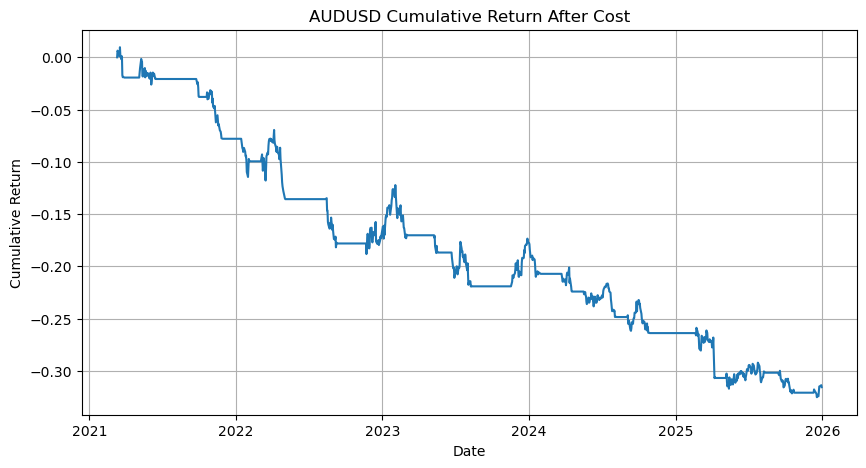

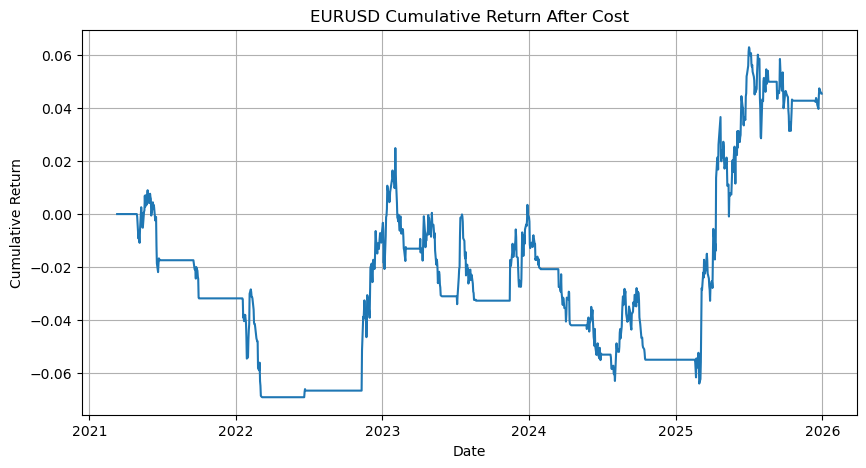

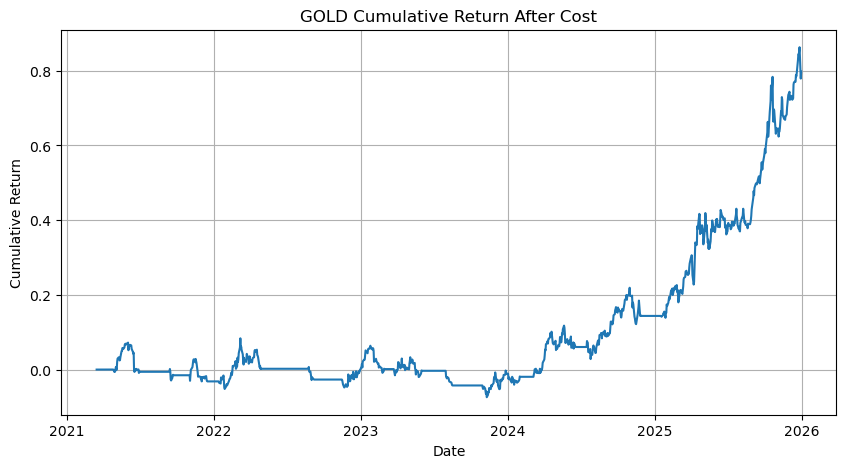

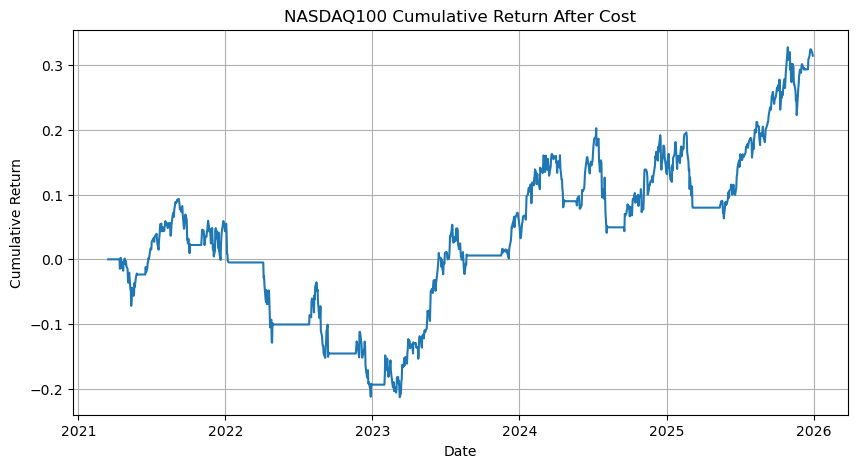

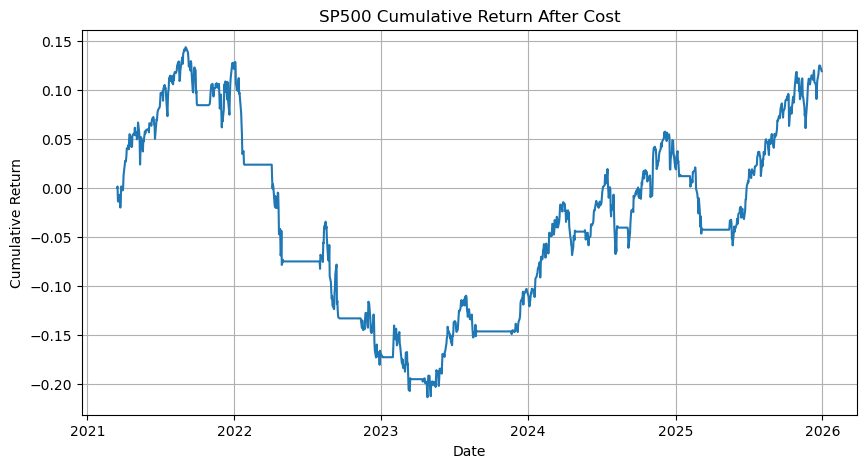

In [32]:
import matplotlib.pyplot as plt

for asset in bt["asset"].unique():
    temp = bt[bt["asset"] == asset]
    plt.figure(figsize=(10, 5))
    plt.plot(temp["Date"], temp["cumulative_return_after_cost"])
    plt.title(f"{asset} Cumulative Return After Cost")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.show()

# 画回撤图：

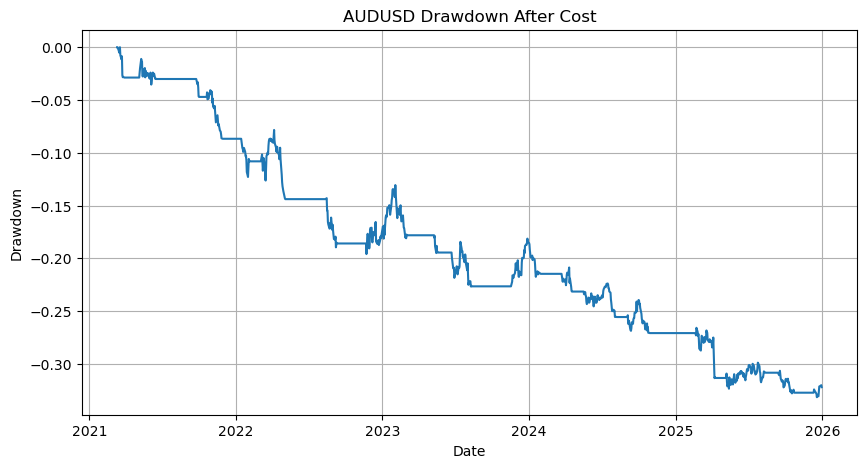

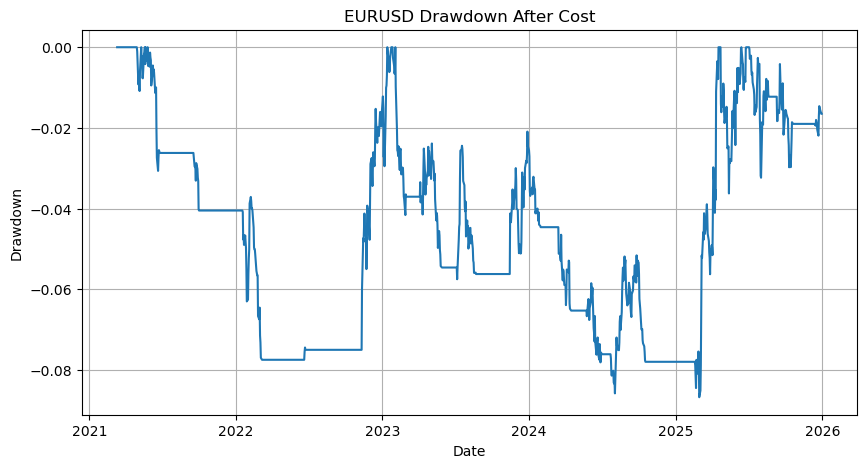

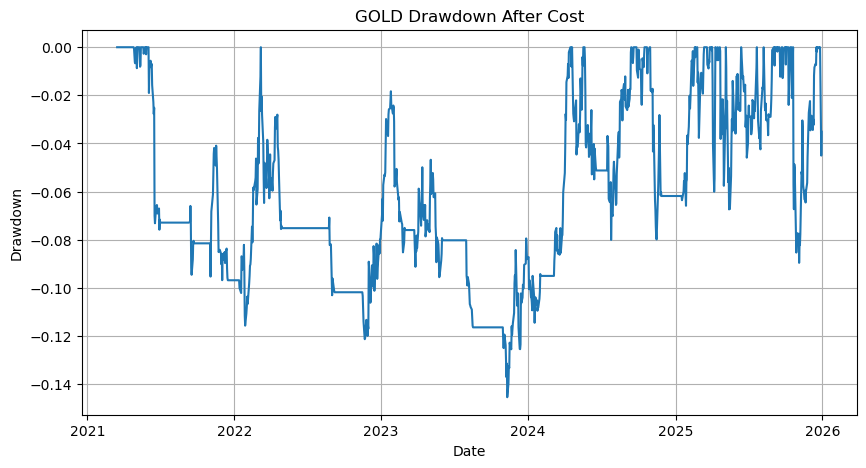

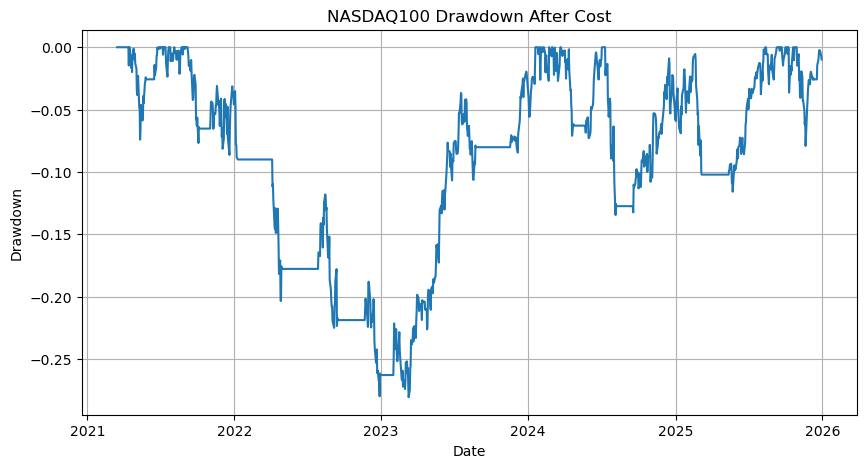

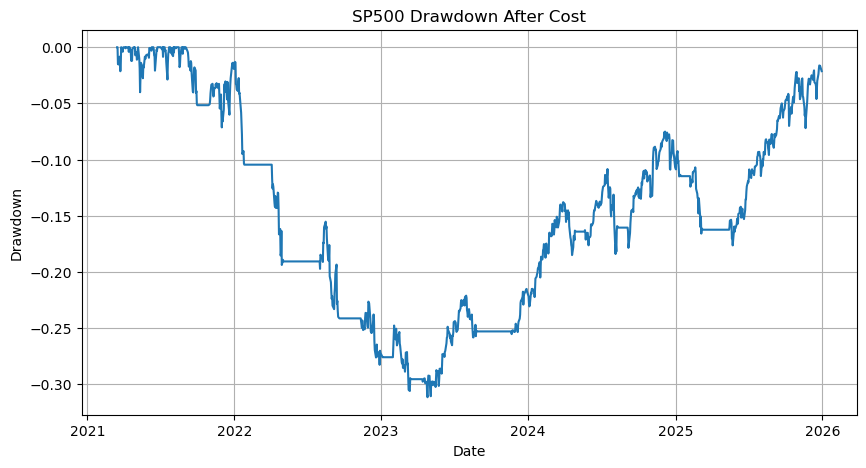

In [33]:
for asset in bt["asset"].unique():
    temp = bt[bt["asset"] == asset]
    plt.figure(figsize=(10, 5))
    plt.plot(temp["Date"], temp["drawdown_after_cost"])
    plt.title(f"{asset} Drawdown After Cost")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True)
    plt.show()

# 画 Sharpe Ratio 对比：

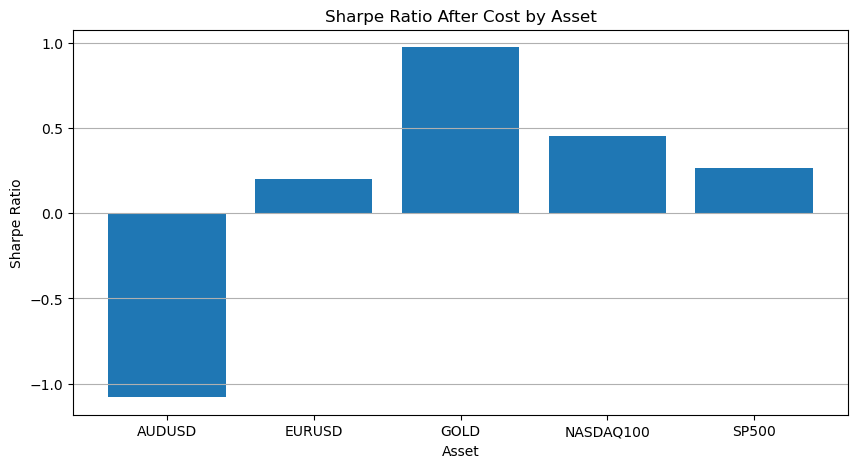

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(performance_summary["asset"], performance_summary["sharpe_ratio_after_cost"])
plt.title("Sharpe Ratio After Cost by Asset")
plt.xlabel("Asset")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y")
plt.show()

# Step 6: SQL-based Trading Performance Analysis with DuckDB
基于 SQL 的交易绩效分析与 DuckDB

In [35]:
!pip install duckdb

In [36]:
import duckdb
import pandas as pd
conn = duckdb.connect("trading_analytics.duckdb")

In [37]:
conn.register("bt_df", bt)
conn.register("performance_summary_df", performance_summary)

conn.execute("""
CREATE OR REPLACE TABLE trade_performance AS
SELECT * FROM bt_df
""")

conn.execute("""
CREATE OR REPLACE TABLE performance_summary AS
SELECT * FROM performance_summary_df
""")

In [38]:
conn.execute("SHOW TABLES").df()

,name
0,bt_df
1,performance_summary
2,performance_summary_df
3,trade_performance


## Step 6.1 查询资产级别表现

In [39]:
query = """
SELECT
    asset,
    ROUND(cumulative_return_after_cost, 4) AS cumulative_return_after_cost,
    ROUND(annualised_return_after_cost, 4) AS annualised_return_after_cost,
    ROUND(annualised_volatility_after_cost, 4) AS annualised_volatility_after_cost,
    ROUND(sharpe_ratio_after_cost, 4) AS sharpe_ratio_after_cost,
    ROUND(max_drawdown_after_cost, 4) AS max_drawdown_after_cost,
    ROUND(win_rate_after_cost, 4) AS win_rate_after_cost,
    ROUND(exposure, 4) AS exposure
FROM performance_summary
ORDER BY sharpe_ratio_after_cost DESC;
"""

sql_performance = conn.execute(query).df()
sql_performance

,asset,cumulative_return_after_cost,annualised_return_after_cost,annualised_volatility_after_cost,sharpe_ratio_after_cost,max_drawdown_after_cost,win_rate_after_cost,exposure
0,GOLD,0.7974,0.1302,0.1349,0.9754,-0.1455,0.3529,0.6305
1,NASDAQ100,0.3149,0.0589,0.1508,0.4552,-0.2806,0.3593,0.6598
2,SP500,0.1189,0.0238,0.1134,0.2641,-0.3117,0.3693,0.6946
3,EURUSD,0.0455,0.0090,0.0507,0.2021,-0.0867,0.2000,0.4488
4,AUDUSD,-0.3155,-0.0736,0.0686,-1.0801,-0.3316,0.2112,0.4576


这张表格回答 哪个资产的扣成本后表现最好？哪个资产 Sharpe Ratio 最高？哪个资产回撤最大？

## Step 6.2 查询交易成本影响

In [40]:
query = """
SELECT
    asset,
    ROUND(total_transaction_cost, 6) AS total_transaction_cost,
    ROUND(total_slippage_cost, 6) AS total_slippage_cost,
    ROUND(total_cost, 6) AS total_cost,
    ROUND(cost_impact, 4) AS cost_impact,
    total_trades
FROM performance_summary
ORDER BY total_cost DESC;
"""

sql_cost_impact = conn.execute(query).df()
sql_cost_impact

,asset,total_transaction_cost,total_slippage_cost,total_cost,cost_impact,total_trades
0,NASDAQ100,0.00750,0.034926,0.042426,0.0569,25.0
1,SP500,0.00575,0.024663,0.030413,0.0346,23.0
2,GOLD,0.00500,0.022222,0.027222,0.0497,25.0
3,AUDUSD,0.00245,0.021099,0.023549,0.0163,35.0
4,EURUSD,0.00155,0.013008,0.014558,0.0153,31.0


哪个资产的交易成本最高？成本主要来自 spread 还是 slippage？

## Step 6.3 按年份分析策略表现

In [41]:
query = """
SELECT
    asset,
    EXTRACT(YEAR FROM Date) AS trading_year,
    ROUND(EXP(SUM(LN(1 + strategy_return_after_cost))) - 1, 4) AS annual_return_after_cost,
    ROUND(SUM(total_cost), 6) AS annual_total_cost,
    ROUND(AVG(volatility_20d), 6) AS avg_volatility_20d,
    ROUND(SUM(turnover), 0) AS annual_trades
FROM trade_performance
GROUP BY asset, trading_year
ORDER BY asset, trading_year;
"""
#SQL 里计算复利累计收益 EXP(SUM(LN(1 + strategy_return_after_cost))) - 1 == (1 + returns).prod() - 1
sql_annual = conn.execute(query).df()
sql_annual

,asset,trading_year,annual_return_after_cost,annual_total_cost,avg_volatility_20d,annual_trades
0,AUDUSD,2021,-0.0779,0.004919,0.005321,8.0
1,AUDUSD,2022,-0.0985,0.005415,0.007898,7.0
2,AUDUSD,2023,-0.0097,0.004396,0.006782,6.0
3,AUDUSD,2024,-0.1056,0.003983,0.005253,7.0
4,AUDUSD,2025,-0.0703,0.004836,0.005689,7.0
5,EURUSD,2021,-0.0318,0.001307,0.003397,4.0
6,EURUSD,2022,0.0248,0.005173,0.005991,9.0
7,EURUSD,2023,0.0077,0.003079,0.004640,6.0
8,EURUSD,2024,-0.0548,0.002584,0.003611,7.0
9,EURUSD,2025,0.1063,0.002415,0.004836,5.0


## Step 6.4 高波动市场下的滑点分析

In [48]:
query = """
SELECT
    asset,
    ROUND(AVG(strategy_return_after_cost), 6) AS avg_return_after_cost,
    ROUND(AVG(volatility_20d), 6) AS avg_volatility,
    ROUND(AVG(slippage_cost), 6) AS avg_slippage_cost,
    ROUND(SUM(total_cost), 6) AS total_cost,
    ROUND(SUM(turnover), 0) AS total_trades
FROM trade_performance
WHERE volatility_20d > (
    SELECT AVG(volatility_20d)
    FROM trade_performance
)
GROUP BY asset
ORDER BY avg_slippage_cost DESC;
"""

sql_high_volatility = conn.execute(query).df()
sql_high_volatility

,asset,avg_return_after_cost,avg_volatility,avg_slippage_cost,total_cost,total_trades
0,EURUSD,0.000667,0.008928,0.000034,0.000940,1.0
1,NASDAQ100,-0.000083,0.014786,0.000034,0.040282,23.0
2,SP500,-0.000255,0.012923,0.000033,0.024450,17.0
3,AUDUSD,-0.000663,0.010574,0.000027,0.003545,3.0
4,GOLD,0.000303,0.011322,0.000020,0.016095,13.0


在高波动时期，哪些资产的滑点成本更明显？

## Step 6.5 保存 SQL 查询结果

In [51]:
import os
os.makedirs("../sql", exist_ok=True)

sql_performance.to_csv("../data/sql_performance_summary.csv", index=False)
sql_cost_impact.to_csv("../data/sql_cost_impact.csv", index=False)
sql_annual.to_csv("../data/sql_annual_performance.csv", index=False)
sql_high_volatility.to_csv("../data/sql_high_volatility_analysis.csv", index=False)

# Step 7: Dashboard Data Preparation and Visualisation

In [52]:
dashboard_data = bt[
    [
        "Date",
        "asset",
        "Close",
        "daily_return",
        "position",
        "turnover",
        "strategy_return_before_cost",
        "strategy_return_after_cost",
        "transaction_cost",
        "slippage_cost",
        "total_cost",
        "cumulative_return_before_cost",
        "cumulative_return_after_cost",
        "equity_curve_after_cost",
        "drawdown_after_cost",
        "volatility_20d"
    ]
].copy()

dashboard_data.to_csv("../data/dashboard_data.csv", index=False)

dashboard_data.head()

Price,Date,asset,Close,daily_return,position,turnover,strategy_return_before_cost,strategy_return_after_cost,transaction_cost,slippage_cost,total_cost,cumulative_return_before_cost,cumulative_return_after_cost,equity_curve_after_cost,drawdown_after_cost,volatility_20d
0,2021-03-11,AUDUSD,0.773200,0.001836,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.007511
1,2021-03-12,AUDUSD,0.778762,0.007193,1.0,1.0,0.007193,0.006359,0.00007,0.000764,0.000834,0.007193,0.006359,1.006359,0.000000,0.007639
2,2021-03-15,AUDUSD,0.776300,-0.003161,1.0,0.0,-0.003161,-0.003161,0.00000,0.000000,0.000000,0.004009,0.003178,1.003178,-0.003161,0.007672
3,2021-03-16,AUDUSD,0.775014,-0.001657,1.0,0.0,-0.001657,-0.001657,0.00000,0.000000,0.000000,0.002345,0.001515,1.001515,-0.004813,0.007651
4,2021-03-17,AUDUSD,0.774557,-0.000589,1.0,0.0,-0.000589,-0.000589,0.00000,0.000000,0.000000,0.001755,0.000926,1.000926,-0.005399,0.007521


## 累计收益曲线-用来展示每个资产的策略表现。

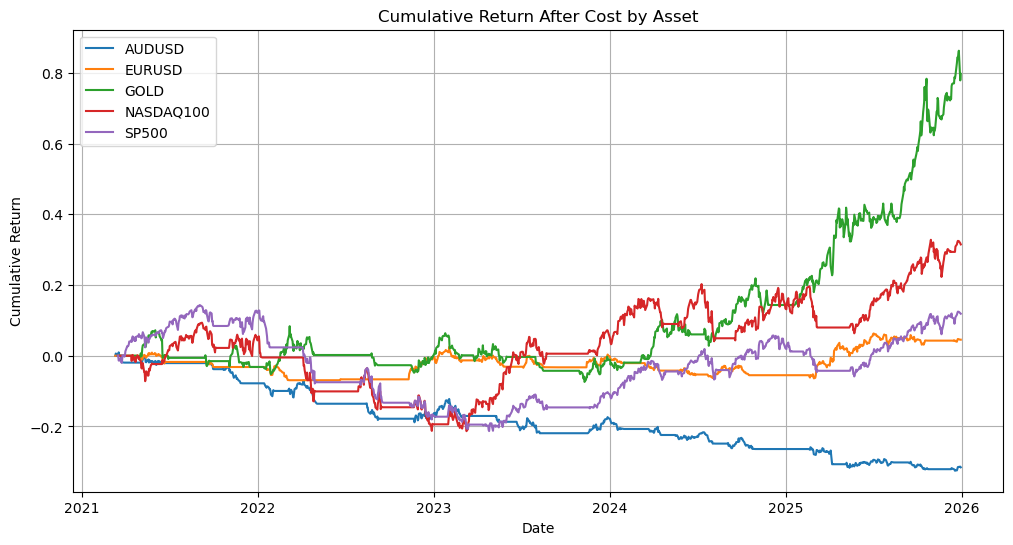

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for asset in dashboard_data["asset"].unique():
    temp = dashboard_data[dashboard_data["asset"] == asset]
    plt.plot(temp["Date"], temp["cumulative_return_after_cost"], label=asset)

plt.title("Cumulative Return After Cost by Asset")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

扣除交易成本后，哪个资产的累计收益表现最好？

## 最大回撤曲线-哪些资产经历了更深的回撤？

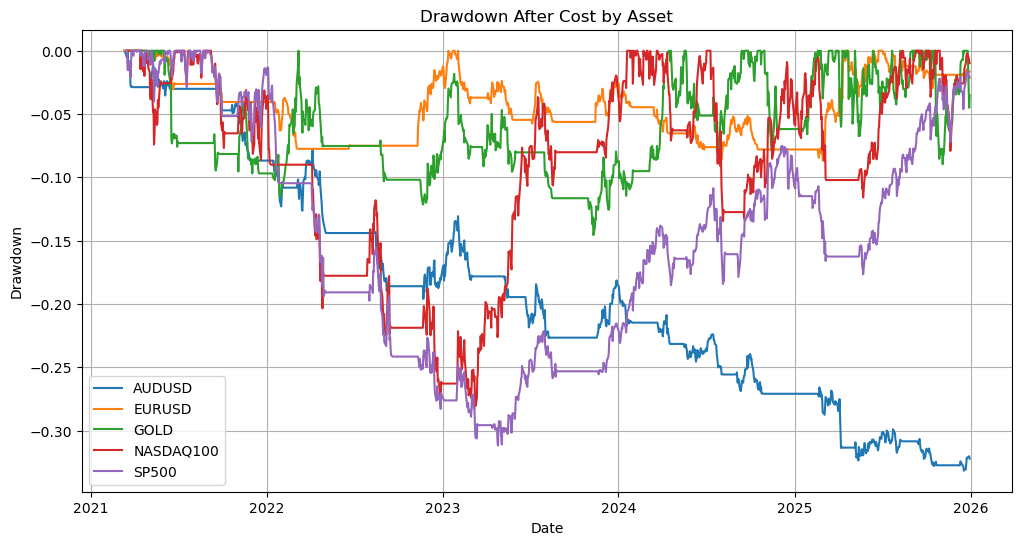

In [54]:
plt.figure(figsize=(12, 6))

for asset in dashboard_data["asset"].unique():
    temp = dashboard_data[dashboard_data["asset"] == asset]
    plt.plot(temp["Date"], temp["drawdown_after_cost"], label=asset)

plt.title("Drawdown After Cost by Asset")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Sharpe Ratio 对比--哪个资产的风险调整后收益最好？

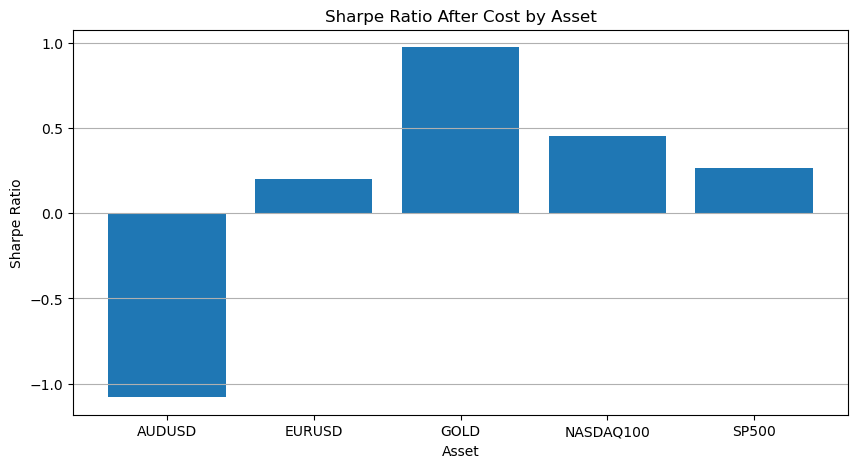

In [55]:
plt.figure(figsize=(10, 5))

plt.bar(
    performance_summary["asset"],
    performance_summary["sharpe_ratio_after_cost"]
)

plt.title("Sharpe Ratio After Cost by Asset")
plt.xlabel("Asset")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y")
plt.show()

## Total Cost by Asset 哪个资产受到交易成本影响最大？

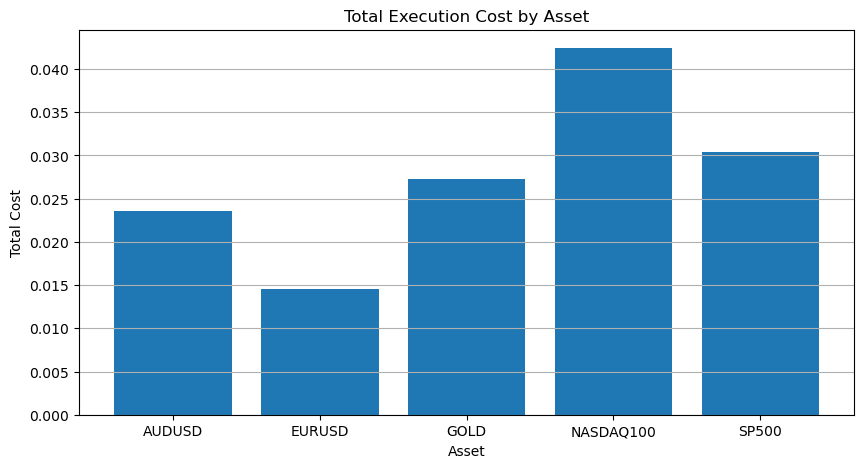

In [56]:
plt.figure(figsize=(10, 5))

plt.bar(
    performance_summary["asset"],
    performance_summary["total_cost"]
)

plt.title("Total Execution Cost by Asset")
plt.xlabel("Asset")
plt.ylabel("Total Cost")
plt.grid(axis="y")
plt.show()

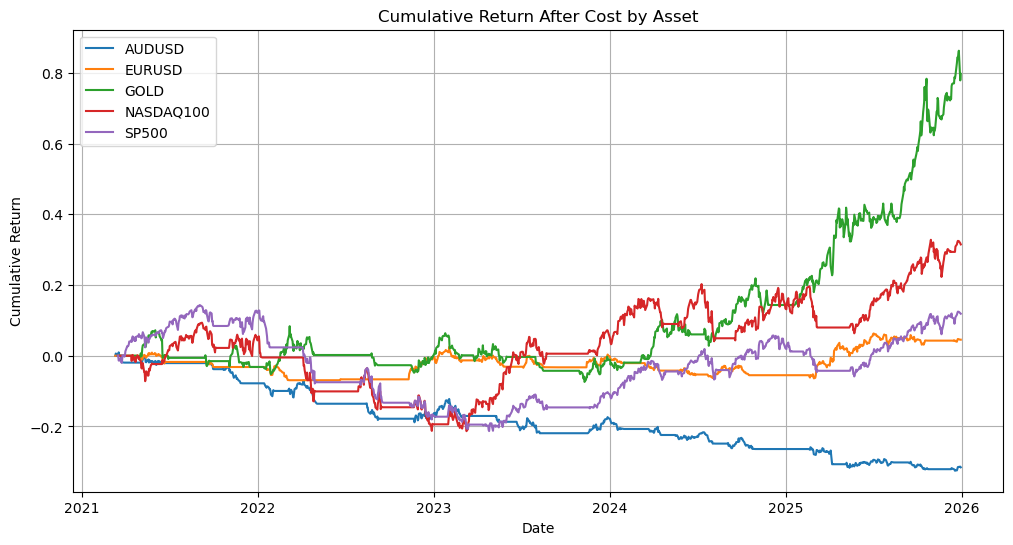

In [57]:
import os

os.makedirs("../dashboard", exist_ok=True)

plt.figure(figsize=(12, 6))
for asset in dashboard_data["asset"].unique():
    temp = dashboard_data[dashboard_data["asset"] == asset]
    plt.plot(temp["Date"], temp["cumulative_return_after_cost"], label=asset)

plt.title("Cumulative Return After Cost by Asset")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.savefig("../dashboard/cumulative_return_after_cost.png", dpi=300, bbox_inches="tight")
plt.show()